# Health Analytics (COMS5027A/FAMH4004A) 2026

# Lab 2 - ML Evaluation in Health Analytics

## Instructions

* Run all the code cells in chronological order.
* Put your names and student numbers in the indicated cell in the exact indicated format.
* You cannot use additional libraries to the ones imported already for you.
* Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
* Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
* Do not delete the answer code cells and recreate them. If you accidentally delete one, you must redownload the notebook.
* Answers must be computed programmatically. Computing by hand and simply setting the variable to that value will lead to a mark of zero since these will not be valid on the private test cases.

## Imports

In [1]:
# RUN THIS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
sns.set_theme()

## Student Details

Populate `student_names` and `student_numbers` with the full names and student numbers of each group member in the same order.

Example:

```
student_names = ["Jane Doe", "John Doe"]
student_numbers = ["123456", "654321"]  # The elements of this list are strings and must be surrounded by quotes!


```

In [ ]:
student_names = ["Odwa Yamile"]  # Provide the FULL name of each group member as it appears on Moodle
student_numbers = ["2593714"]  # Provide the student number of each group member in the same order as student names. Ensure the student numbers are represented as strings

assert len(student_names) == len(student_numbers), "All student names must have an associated student number and vice-versa"
assert np.all([type(x) == str for x in student_numbers]), "All student numbers must be represented as strings"

## Public Test Cases

The 'public test cases' are used for you to check your answers, and sometimes act as a heuristic for if your answer is correct or not. Your answers will be marked by hand and/or programatically using hidden test cases.

# Data Ingestion & Exploration

**Context:** A new, highly infectious disease ("Pathogen X") is being monitored across 1000 regional health districts. A baseline Machine Learning model has been deployed to predict which districts will experience an outbreak this week. You need to evaluate the clinical utility of this model.

The below code creates the data associated with this fictitious disease.

In [2]:
# RUN THIS & DO NOT MODIFY
# Simulating the system-level Pathogen X dataset predictions
np.random.seed(42)

# Generate True Labels (950 safe, 50 outbreaks)
y_true_neg = np.zeros(950, dtype=int)
y_true_pos = np.ones(50, dtype=int)

# Generate Predicted Labels for actual negatives (940 TN, 10 FP)
y_pred_neg = np.concatenate([np.zeros(940, dtype=int), np.ones(10, dtype=int)])
np.random.shuffle(y_pred_neg)

# Generate Predicted Labels for actual positives (30 FN, 20 TP)
y_pred_pos = np.concatenate([np.zeros(30, dtype=int), np.ones(20, dtype=int)])
np.random.shuffle(y_pred_pos)

y_true_sim = np.concatenate([y_true_neg, y_true_pos])
y_pred_sim = np.concatenate([y_pred_neg, y_pred_pos])

indices = np.arange(1000)
np.random.shuffle(indices)

df_pathogen = pd.DataFrame({
    'actual_outbreak': y_true_sim[indices],
    'predicted_outbreak': y_pred_sim[indices]
})
df_pathogen.index.name = 'region_id'
df_pathogen.head()

# DO NOT MODIFY ABOVE #

,actual_outbreak,predicted_outbreak
region_id,,
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


#### Question 1

Extract the `actual_outbreak` and `predicted_outbreak` columns from `df_pathogen` into two Pandas Series named `y_true` and `y_pred` respectively.

Note: `y_true` is a common convention for naming the actual labels, and similarly `y_pred` is a common name for the predicted labels.

In [3]:
# STUDENT ANSWER
y_true = df_pathogen['actual_outbreak']
y_pred = df_pathogen['predicted_outbreak']

**Public Test Case**

In [4]:
# RUN THIS & DO NOT MODIFY
if y_true.sum() == 50:
    print("Answer for Q1 (data extraction) is likely correct.")
else:
    print("Answer for Q1 is incorrect.")

Answer for Q1 (data extraction) is likely correct.


#### Question 2

Use Seaborn to plot a countplot of `y_true` to visualize the true (not predicted) prevalence of Pathogen X across the districts. `actual_outbreak` should be on the x-axis and `count` should be on the y-axis.

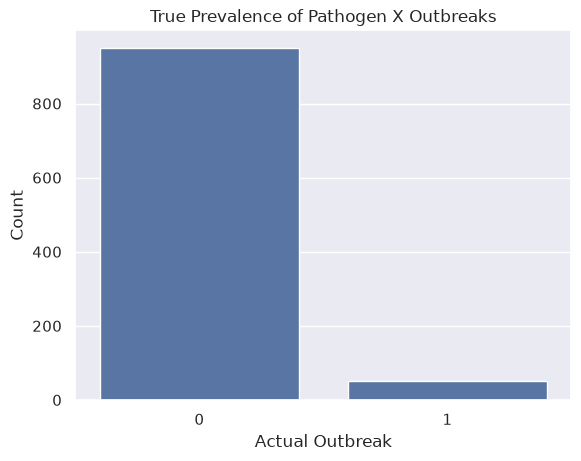

In [5]:
# STUDENT ANSWER
# TODO: Plot the distribution of y_true using sns.countplot
sns.countplot(x=y_true)
plt.xlabel("Actual Outbreak")
plt.ylabel("Count")
plt.title("True Prevalence of Pathogen X Outbreaks")
plt.show()

# The Confusion Matrix

Before calculating overall metrics, we must break down the model's predictions into True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

#### Question 3

Compute the confusion matrix using `scikit-learn` and set it to the variable `conf_arr`. DO NOT create a variable called `confusion_matrix` as this will overwrite the associated method.

Programmatically* extract the values for true positives (`tp`), false negatives (`fn`), false positives (`fp`), and true negatives(`tn`). Assign these values to the associated variables `tn`, `fp`, `fn`, and `tp`.

Note: The index (0, 0) corresponds to the top left of the NumPy array. Additionally, scikit-learn orders rows/cols by class label 0, then 1. Therefore (0,0) is TN, (0,1) is FP, (1,0) is FN, and (1,1) is TP.


In [6]:
# STUDENT ANSWER
conf_arr = confusion_matrix(y_true, y_pred)

tn = conf_arr[0, 0]
fp = conf_arr[0, 1]
fn = conf_arr[1, 0]
tp = conf_arr[1, 1]

**Public Test Case**

In [7]:
# RUN THIS & DO NOT MODIFY
if tn + fp + fn + tp == 1000:
    print("Answer for Q3 is likely correct.")
else:
    print("Answer for Q3 is incorrect.")

Answer for Q3 is likely correct.


#### Question 4

Create an annotated heatmap of the confusion matrix using Seaborn (`sns.heatmap`) where the annotations correspond to the associated values in the confusion matrix. Ensure the axes are appropriately labeled "Actual" and "Predicted".

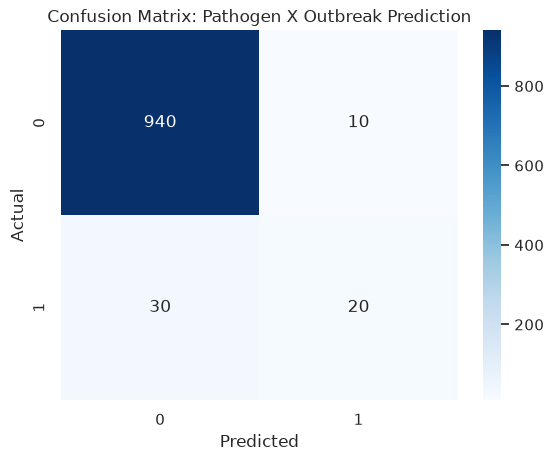

In [8]:
# STUDENT ANSWER
# TODO: Create confusion matrix heatmap

sns.heatmap(conf_arr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Pathogen X Outbreak Prediction")
plt.show()

# Overall Performance Metrics: Accuracy & Error

#### Question 5

Calculate the overall accuracy using `accuracy_score` and assign it to `model_accuracy`. Calculate the error rate mathematically according to the equation in the lecture and assign it to `model_error`.

In [9]:
# STUDENT ANSWER
model_accuracy = accuracy_score(y_true, y_pred)
model_error = 1 - model_accuracy

print(f"Accuracy: {model_accuracy}")
print(f"Error: {model_error}")

Accuracy: 0.96
Error: 0.040000000000000036


**Public Test Case**

In [10]:
# RUN THIS & DO NOT MODIFY
if np.isclose(model_accuracy, 0.96) and np.isclose(model_error, 0.04):
    print("Answer for Q5 is likely correct.")
else:
    print("Answer for Q5 is incorrect.")

Answer for Q5 is likely correct.


#### Question 6

Look at your calculated `model_accuracy` (which should be 0.96, i.e. 96%) and the countplot you generated in Question 2. Explain why the model achieved such a high accuracy score despite the heatmap showing it performed poorly on predicting actual outbreaks.

*Answer in the Markdown cell below.*

YOUR ANSWER GOES HERE - Double click this cell.

The model got 96% accuracy, but that number is misleading. Out of 1000 districts, 950 were actually safe and only 50 actually had an outbreak. The model was very good at spotting safe districts, and since safe districts make up 95% of the data, this alone pushed accuracy up to 96%.

But when we look at the districts that actually had an outbreak, the model only caught 20 out of 50, it completely missed 30 real outbreaks. Accuracy doesn't show this problem because it just adds up all the correct predictions together, without caring which class they came from. So a model can look excellent overall while actually failing at the one job that matters most which is catching real outbreaks before they spread.

# Public Health Impact Metrics: Miss & False Alarm

In health systems, the *type* of error matters significantly.

* Miss Rate (False Negative Rate): $miss=\frac{FN}{TP+FN}$
* False Alarm Rate (False Positive Rate): $false\_alarm=\frac{FP}{FP+TN}$

#### Question 7

Using the numerical variables extracted in Question 3, mathematically calculate the Miss Rate and False Alarm Rate. Assign them to `miss_rate` and `false_alarm_rate`.

In [11]:
# STUDENT ANSWER
miss_rate = fn / (tp + fn)
false_alarm_rate = fp / (fp + tn)

print("Miss = ", miss_rate)
print("False Alarm Rate = ", false_alarm_rate)

Miss =  0.6
False Alarm Rate =  0.010526315789473684


**Public Test Case**

In [12]:
# RUN THIS & DO NOT MODIFY
if miss_rate == 0.6:
    print("Answer for Q7 is likely correct.")
else:
    print("Answer for Q7 is incorrect.")

Answer for Q7 is likely correct.


#### Question 8

Review your computed `miss_rate`. Exactly how many regional health districts experiencing a Pathogen X outbreak were classified as "safe" by this model? From an epidemiological perspective, what is the systemic risk of deploying a model with this specific Miss Rate?

*Answer in the Markdown cell below.*

YOUR ANSWER GOES HERE - Double click this cell.

The model identified 30 regional health districts as safe even though they were actually facing a Pathogen X outbreak. This results in a Miss Rate of 60%, indicating that the model missed most of the actual outbreaks. The systemic risk involved is significant, if health authorities depend on this model to determine where to allocate resources, 30 districts with an ongoing, spreading disease would not receive any help.

Since Pathogen X spreads easily, an unnoticed outbreak in just one district can escalate before anyone is aware, potentially leading to a much larger public health emergency. So basically a high miss rate in this situation isn't merely a statistical flaw, it means lost chances to control a disease early on, which can turn a small, manageable outbreak into a widespread epidemic.

# Resource Constraint Metrics: Recall & Precision

Now we shift the focus from epidemiological tracking to resource management. Precision and recall are highly important when healthcare resources are constrained and interventions must only be deployed where required.

#### Question 9

Calculate Recall and Precision using the imported `scikit-learn` functions. Assign them to `model_recall` and `model_precision`.

In [13]:
# STUDENT ANSWER
model_recall = recall_score(y_true, y_pred)
model_precision = precision_score(y_true, y_pred)

print("Recall:", model_recall)
print("Precision:", model_precision)

Recall: 0.4
Precision: 0.6666666666666666


#### Question 10

Create a Seaborn or Matplotlib bar plot comparing `model_accuracy`, `model_recall`, and `model_precision` side-by-side to visually highlight the disparity in these metrics.

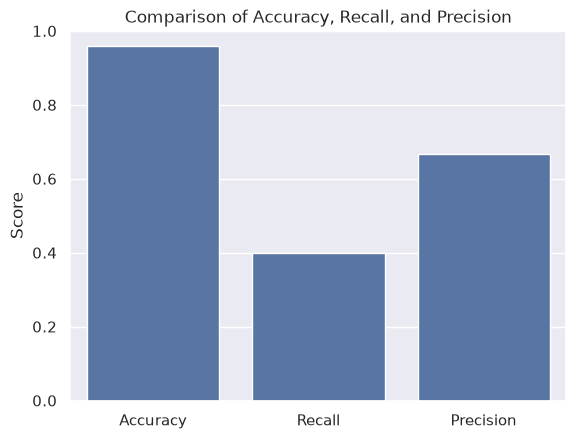

In [14]:
# STUDENT ANSWER
# TODO: Create a bar plot comparing the three metrics

metrics = ['Accuracy', 'Recall', 'Precision']
values = [model_accuracy, model_recall, model_precision]

sns.barplot(x=metrics, y=values)
plt.ylabel("Score")
plt.title("Comparison of Accuracy, Recall, and Precision")
plt.ylim(0, 1)
plt.show()

#### Question 11

Based on the `model_precision` score you calculated and the visualization you just created, if the Department of Health mobilizes limited mobile intervention units to **EVERY** region this model predicts as positive, what exact percentage of those deployments will be wasted? Explain why the gap between the Accuracy bar and the Precision bar dictates that this model currently lacks clinical utility and policy relevance.

*Answer in the Markdown cell below.*

YOUR ANSWER GOES HERE - Double click this cell.

If every area marked as positive gets a mobile intervention, around 33.3% of those efforts would be wasted because the model's precision is only about 66.7%.

This is important because while the model's Accuracy is 96%, making it seem very reliable, its Precision at 66.7% and Recall at 40% tell a different story. The high Accuracy is mainly due to the model's ability to correctly identify a large number of safe districts, which is easier because of the class imbalance. However, it struggles with the rare but crucial positive cases. This discrepancy seriously affects the model's usefulness in clinical settings like for policy-making, decision-makers relying on this model would waste a third of their limited mobile units on unnecessary actions and would also miss detecting 60% of actual outbreaks. A model that is this unreliable cannot help in making responsible resource decisions or in effectively containing outbreaks, meaning it currently does not provide the actionable and trustworthy evidence needed for real-world health policy choices.

# END